# NOTEBOOK 2: Forecasting Summer Runoff — An Engineering Perspective
##### AUTHOR: Nick Jadallah
###### AI Acknowledgement: Claude Code was used as a code-generating tool in this project but played no role in the conceptual design of the activity.

### Importing some Python packages/libraries...don't worry about these

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW = "../data/raw"

### Loading and preparing UCRB data...don't worry about these

In [158]:
"""
precipitation --> monthly, NCEI
temperature   --> monthly, NCEI
soil moisture --> monthly, PFCLM baseline storage (SM_storage[cm])
streamflow    --> monthly, naturalized flow at Lees Ferry (the TARGET we're forecasting)
SWE           --> daily, basin-mean across 54 UCRB SNOTEL stations
"""

def water_year(date):
    return date.year if date.month < 10 else date.year + 1

WY_START, WY_END = 1981, 2019

p = pd.read_csv(f"{RAW}/ncei_precip_monthly_v_2.csv", parse_dates=["Date"])
t = pd.read_csv(f"{RAW}/ncei_temp_monthly_v_2.csv", parse_dates=["Date"])
sm = pd.read_csv(f"{RAW}/ucrb_baseline_storage_v_2.csv", index_col=0, parse_dates=True)
flow = pd.read_csv(f"{RAW}/naturalized_flow_leesferry_monthly_v_2.csv", parse_dates=["date"])
swe_daily = pd.read_csv(f"{RAW}/snotel_swe_daily_v_2.csv", parse_dates=["date"])

# basin-mean SWE across all SNOTEL stations, inches, sorted daily series
swe_station_cols = [c for c in swe_daily.columns if c != "date"]
swe_daily["SWE_basin_mean_in"] = swe_daily[swe_station_cols].mean(axis=1, skipna=True) / 25.4
swe_daily = swe_daily.set_index("date")["SWE_basin_mean_in"].sort_index()

p["ym"] = p["Date"].dt.to_period("M")
t["ym"] = t["Date"].dt.to_period("M")
sm["ym"] = sm.index.to_period("M")
flow["ym"] = flow["date"].dt.to_period("M")

ucrb = (
    p[["ym", "precip_cm"]]
    .merge(t[["ym", "temp_degC"]], on="ym")
    .merge(sm[["ym", "SM_storage[cm]"]], on="ym")
    .merge(flow[["ym", "acre_feet"]], on="ym")
)
ucrb["date"] = ucrb["ym"].dt.to_timestamp()
ucrb["month"] = ucrb["date"].dt.month
ucrb["wy"] = ucrb["date"].apply(water_year)
ucrb["precip_in"] = ucrb["precip_cm"] / 2.54
ucrb["temp_F"] = ucrb["temp_degC"] * 9 / 5 + 32
ucrb["SM_cm"] = ucrb["SM_storage[cm]"]
ucrb["flow_maf"] = ucrb["acre_feet"] / 1e6

ucrb = ucrb.set_index("date")[["month", "wy", "precip_in", "temp_F", "SM_cm", "flow_maf"]]

In [159]:
print("**UCRB monthly dataframe**")
display(ucrb.head(10))
print("\n**SWE daily basin-mean (in)**")
display(swe_daily.head())

**UCRB monthly dataframe**


,month,wy,precip_in,temp_F,SM_cm,flow_maf
date,,,,,,
1979-10-01,10,1980,1.161417,48.776,56.379705,0.323532
1979-11-01,11,1980,1.387795,27.086,57.185094,0.384124
1979-12-01,12,1980,0.805906,25.214,57.300077,0.342224
1980-01-01,1,1980,3.106693,25.664,58.128680,0.455115
1980-02-01,2,1980,2.392913,29.390,59.541865,0.621963
1980-03-01,3,1980,1.961417,31.406,61.297460,0.656186
1980-04-01,4,1980,1.068504,41.216,62.475245,1.532843
1980-05-01,5,1980,2.242913,49.496,64.966956,4.410194
1980-06-01,6,1980,0.144882,61.844,63.209673,5.199832



**SWE daily basin-mean (in)**


date
1980-10-01    0.0
1980-10-02    0.0
1980-10-03    0.0
1980-10-04    0.0
1980-10-05    0.0
Name: SWE_basin_mean_in, dtype: float64

# ------------------------------------------------------------------------------------
## PART 1: Build Your Own MLR Model (with the benefit of hindsight)
# ------------------------------------------------------------------------------------

Just like Notebook 1, you'll build a **multiple linear regression (MLR)** model. You
have seven ingredients to choose from, each representing a real physical signal in how
the Upper Colorado River basin generates its summer runoff:

- **SWE (April 1 snowpack)** — historically the single strongest predictor of summer
  runoff in this basin (makes sense — that snow *becomes* the runoff).
- **Fall precipitation** (Sep-Dec total) — a proxy for how wet the ground already was
  heading into winter.
- **Fall soil moisture anomaly** (Sep-Dec average, minus the WY1981-2019 average) —
  another antecedent-wetness proxy, from a model rather than a direct observation.
  Anomaly rather than raw value, so a positive number means "wetter than typical,"
  negative means "drier than typical."
- **Fall temperature** (Sep-Dec average) — could affect early-season snowpack
  development.
- **Fall baseflow** (Sep-Dec total, observed flow at Lees Ferry) — antecedent
  baseflow, a signal of how wet the basin's soil and groundwater already are heading
  into the snow season, the same kind of signal real forecasters (NRCS) use
  operationally alongside SWE and precipitation.
- **Spring precipitation** (Mar-May total) — rain/snow falling *during* the runoff
  season itself.
- **Spring temperature** (Mar-May average) — controls how fast the snowpack melts.

**Your quest**: toggle predictors on and off below, re-run the fit, and see what
happens to R². Try to build the model *you* think best explains Apr-Jul flow — using
full hindsight, i.e. every predictor's real, final value for that water year. (Part 2
is a separate activity — it doesn't use whatever you build here, so feel free to
experiment freely.)

In [160]:
def fall_window_agg(df, col, start_month, end_month, how="mean"):
    """
    Aggregate `col` over a window inside Jul-Dec, attributed to the WATER YEAR THAT
    FOLLOWS the window (e.g. Sep-Dec 2011 -> WY2012) -- fall conditions precede the
    winter/spring of the water year they help predict, so they get attributed forward,
    unlike the usual water_year() convention.
    """
    sub = df[(df["month"] >= start_month) & (df["month"] <= end_month)].copy()
    sub["wy"] = sub.index.year + 1
    grouped = sub.groupby("wy")[col]
    return grouped.sum() if how == "sum" else grouped.mean()


def spring_window_agg(df, col, start_month, end_month, how="mean"):
    """
    Aggregate `col` over a window inside Jan-Sep, attributed to the SAME water year
    (e.g. Mar-May 2012 -> WY2012) -- no cross-year attribution needed here.
    """
    sub = df[(df["month"] >= start_month) & (df["month"] <= end_month)]
    grouped = sub.groupby(sub["wy"])[col]
    return grouped.sum() if how == "sum" else grouped.mean()


def apr_jul_target(df, col="flow_maf"):
    sub = df[(df["month"] >= 4) & (df["month"] <= 7)]
    return sub.groupby(sub["wy"])[col].sum()


swe_april1 = pd.read_csv(f"{RAW}/snotel_swe_april1_v_2.csv")
swe_april1_cols = [c for c in swe_april1.columns if c != "water_year"]
swe_april1["SWE_Apr1_in"] = swe_april1[swe_april1_cols].mean(axis=1, skipna=True) / 25.4
swe_april1 = swe_april1.set_index("water_year")["SWE_Apr1_in"]

# soil moisture as an ANOMALY (value minus the WY1981-2019 period mean), not raw cm
fall_SM_raw = fall_window_agg(ucrb, "SM_cm", 9, 12, how="mean")
fall_SM_period_mean = fall_SM_raw[(fall_SM_raw.index >= WY_START) & (fall_SM_raw.index <= WY_END)].mean()
fall_SM_anom = fall_SM_raw - fall_SM_period_mean

hindsight = pd.DataFrame({
    "SWE_Apr1": swe_april1,
    "fall_precip": fall_window_agg(ucrb, "precip_in", 9, 12, how="sum"),
    "fall_SM_anom": fall_SM_anom,
    "fall_temp": fall_window_agg(ucrb, "temp_F", 9, 12, how="mean"),
    "fall_baseflow": fall_window_agg(ucrb, "flow_maf", 9, 12, how="sum"),
    "spring_precip": spring_window_agg(ucrb, "precip_in", 3, 5, how="sum"),
    "spring_temp": spring_window_agg(ucrb, "temp_F", 3, 5, how="mean"),
    "aprjul_flow": apr_jul_target(ucrb, "flow_maf"),
})
hindsight = hindsight[(hindsight.index >= WY_START) & (hindsight.index <= WY_END)].dropna()

print(f"n = {len(hindsight)} water years, WY{hindsight.index.min()}-WY{hindsight.index.max()}")
display(hindsight.head())

n = 39 water years, WY1981-WY2019


,SWE_Apr1,fall_precip,fall_SM_anom,fall_temp,fall_baseflow,spring_precip,spring_temp,aprjul_flow
1981,10.552830,3.862205,1.553619,42.6875,1.866994,5.313780,44.354,5.320822
1982,21.843137,6.342913,1.316665,42.1925,2.032594,4.072441,41.660,11.290933
1983,20.130189,7.100000,3.204311,38.6735,3.086901,5.905118,40.016,17.083297
1984,20.414815,8.020472,3.889522,40.6220,2.660268,3.932677,41.768,18.027352
1985,18.505556,6.350000,4.342270,38.8490,2.951771,5.321654,44.078,15.184306


### YOUR QUEST: toggle predictors below, then re-run the next two cells

In [186]:
# --- toggle predictors on/off ---
USE_SWE = False
USE_FALL_P = True
USE_FALL_SM = True
USE_FALL_T = True
USE_FALL_BASEFLOW = True
USE_SPRING_P = False
USE_SPRING_T = False

#### Can ignore the code here. This is just doing some legwork to help us get our answers.

In [187]:
predictor_cols = []
if USE_SWE: predictor_cols.append("SWE_Apr1")
if USE_FALL_P: predictor_cols.append("fall_precip")
if USE_FALL_SM: predictor_cols.append("fall_SM_anom")
if USE_FALL_T: predictor_cols.append("fall_temp")
if USE_FALL_BASEFLOW: predictor_cols.append("fall_baseflow")
if USE_SPRING_P: predictor_cols.append("spring_precip")
if USE_SPRING_T: predictor_cols.append("spring_temp")

X = hindsight[predictor_cols]
y = hindsight["aprjul_flow"]

X_mean, X_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()
Xz = (X - X_mean) / X_std
yz = (y - y_mean) / y_std

beta, *_ = np.linalg.lstsq(Xz.values, yz.values, rcond=None)
y_pred_z = Xz.values @ beta
r2 = np.corrcoef(y_pred_z, yz.values)[0, 1] ** 2
y_pred = y_pred_z * y_std + y_mean

print(f"Predictors used: {predictor_cols}")
print(f"n = {len(y)}, R² = {r2:.3f}")

Predictors used: ['fall_precip', 'fall_SM_anom', 'fall_temp', 'fall_baseflow']
n = 39, R² = 0.573


### PLOTTED RESULTS -- TAKE NOTE!

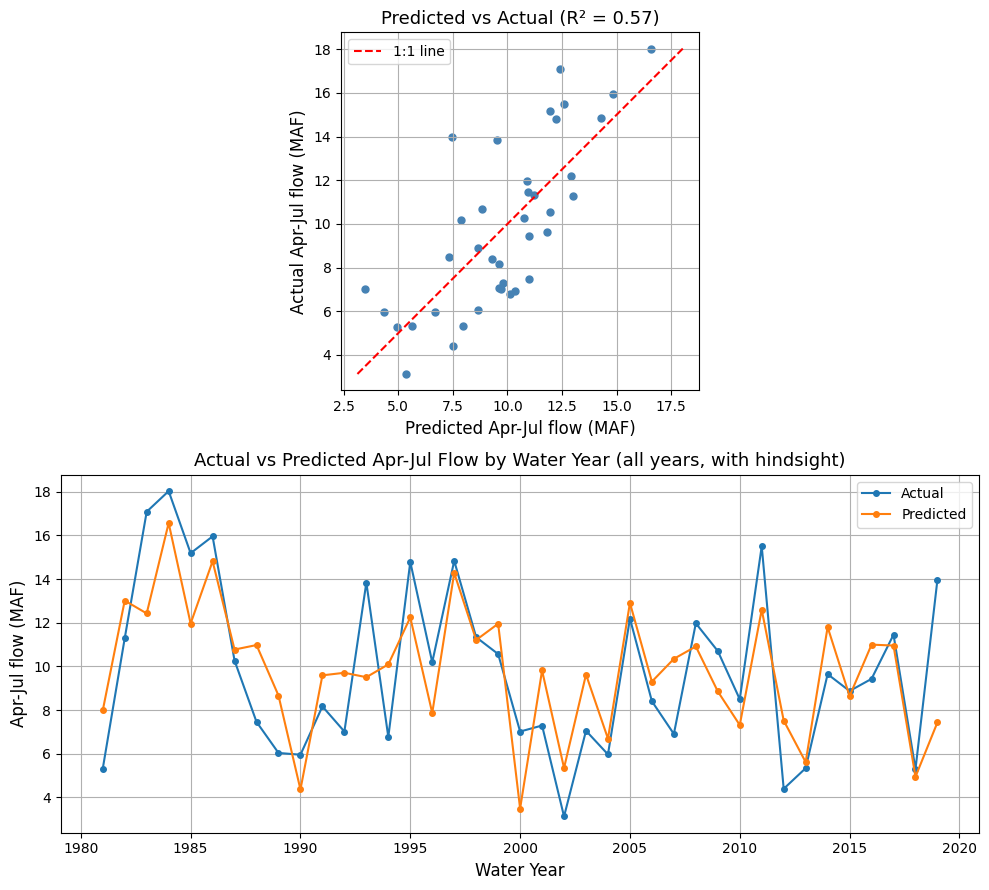

In [188]:
fig = plt.figure(figsize=(10, 9))
ax_scatter = fig.add_subplot(2, 1, 1)
ax_ts = fig.add_subplot(2, 1, 2)

ax_scatter.scatter(y_pred, y, s=25, color="steelblue")
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax_scatter.plot(lims, lims, color="red", linestyle="--", label="1:1 line")
ax_scatter.set_xlabel("Predicted Apr-Jul flow (MAF)", fontsize=12)
ax_scatter.set_ylabel("Actual Apr-Jul flow (MAF)", fontsize=12)
ax_scatter.set_title(f"Predicted vs Actual (R\u00b2 = {r2:.2f})", fontsize=13)
ax_scatter.legend()
ax_scatter.grid()
ax_scatter.set_box_aspect(1)

ax_ts.plot(y.index, y.values, label="Actual", marker="o", markersize=4)
ax_ts.plot(y.index, y_pred, label="Predicted", marker="o", markersize=4)
ax_ts.set_xlabel("Water Year", fontsize=12)
ax_ts.set_ylabel("Apr-Jul flow (MAF)", fontsize=12)
ax_ts.set_title("Actual vs Predicted Apr-Jul Flow by Water Year (all years, with hindsight)", fontsize=13)
ax_ts.legend()
ax_ts.grid()

plt.tight_layout()
plt.show()

### **Discuss** and prepare to share your observations with the class:
#### - Look at the time series plot -- are there specific years your model consistently over- or under-predicts? Any guesses why?
#### - Did adding more predictors meaningfully improve R², or mostly not? What does that tell you?
#### - This model got to "cheat" -- it used each variable's real, final value for the whole water year, including months that haven't happened yet if you were standing on Jan 1. Which of your predictors would NOT actually be available yet on Jan 1 of that year?

# ------------------------------------------------------------------------------------
## PART 2: An Operational Forecast, Issued Three Times
# ------------------------------------------------------------------------------------

This part is separate from Part 1 -- it doesn't use whatever predictors you toggled on
above. Instead, it's a fixed, ready-to-run demo of an operational-style forecast, built
around four ingredients -- **SWE-to-date**, **temperature**, **precipitation**, and
**antecedent baseflow** -- grouped into two fixed chunks instead of one continuous
window:

- **Chunk 1 (Oct-Dec)** -- the "initial condition." By Jan 1 (the earliest issue
  date), this has already fully happened, so it's always real/observed, at every
  issue date, in every version below -- there's nothing to borrow here, ever. Chunk 1
  includes not just temperature and precipitation but also **antecedent baseflow**
  (Oct-Dec observed flow at Lees Ferry) -- a signal of how wet the basin's soil and
  groundwater already are heading into the snow season, the same kind of signal real
  forecasters (NRCS) use operationally alongside SWE and precipitation.
- **Chunk 2 (Jan-Apr)** -- the "prediction chunk." This is where a real forecast
  standing on Jan 1, Feb 1, or Mar 1 genuinely doesn't know the future yet -- and even
  by Mar 1 (our latest issue date), April itself still hasn't happened. Whichever
  months in this chunk have already happened by the issue date use their real
  observed value; whichever haven't yet borrow that same historical year's real value
  instead -- the same idea CBRFC's real **Ensemble Streamflow Prediction (ESP)**
  method uses. The spread of predictions across all borrowed years **is** the
  forecast -- not a single number, but a range, summarized as a 10th / 50th (most
  likely) / 90th percentile, the same way CBRFC and the AOP report their own
  forecasts.

Concretely, for Chunk 2:
- **Jan 1**: Jan-Apr all borrowed (nothing in Chunk 2 has happened yet).
- **Feb 1**: Jan real, Feb-Apr borrowed.
- **Mar 1**: Jan-Feb real, Mar-Apr borrowed -- notice Chunk 2 never becomes fully real
  at any of our three issue dates, since April always has to be borrowed. That keeps a
  real source of ensemble spread alive even at our latest forecast.

We'll build **two versions** of Chunk 2 side by side, so you can see whether it
matters:
- **Version A** -- Chunk 2 collapsed into one mean-temp / sum-precip value, the same
  treatment as Chunk 1.
- **Version B** -- Chunk 2 kept as four separate months (Jan, Feb, Mar, Apr), each
  with its own predictor, so the regression can fit a different coefficient for a hot
  January than for a hot April. Physically, that's plausible -- a January warm spell
  mostly affects low/mid-elevation snowpack, while an April warm spell is much closer
  to peak melt timing.

**SWE-to-date** works the same way it did conceptually in Part 1, just recomputed at
each issue date instead of fixed at April 1.

Only years *before* the forecast year are eligible as historical stand-ins -- a real
forecaster standing on Jan 1, 2012 couldn't borrow a weather pattern from 2015, because
2015 hadn't happened yet either.

We'll practice on a real, already-happened water year so you can check your work at
the end: **WY2012**, a real drought year (Apr-Jul flow was only 4.40 MAF, well below
the ~9 MAF long-term average). `AOP12.pdf` in the project folder is Reclamation's real
Annual Operating Plan from around this period, if you want to see the real-world
version of this document.

**Your quest**: run the three forecast cells below in order (Jan 1, Feb 1, Mar 1)
and compare Version A against Version B side by side at each issue date -- does
letting each month have its own coefficient actually change the forecast, or does it
mostly wash out?

In [164]:
FORECAST_WY = 2012

# ENSEMBLE_PRIOR_YEARS_ONLY = True mimics real forecasting: a forecaster standing on
# Jan 1, 2012 could only have used weather traces AND calibrated a model from years
# that had already happened (WY1981-2011) -- WY2015 simply didn't exist as data yet.
# Set to False to use every other year in the record instead (bigger ensemble, but
# no longer honest to what a real-time forecaster would have had available).
ENSEMBLE_PRIOR_YEARS_ONLY = True

if ENSEMBLE_PRIOR_YEARS_ONLY:
    ensemble_pool = sorted(wy for wy in hindsight.index if wy < FORECAST_WY)
else:
    ensemble_pool = sorted(wy for wy in hindsight.index if wy != FORECAST_WY)

print(f"Forecasting Apr-Jul {FORECAST_WY} summer runoff using: SWE-to-date, Chunk 1 (Oct-Dec), Chunk 2 (Jan-Apr)")
print("Comparing Version A (Chunk 2 aggregated) vs Version B (Chunk 2 per-month)")
print(f"Ensemble pool: {len(ensemble_pool)} historical years ({ensemble_pool[0]}-{ensemble_pool[-1]}).")

Forecasting Apr-Jul 2012 summer runoff using: SWE-to-date, Chunk 1 (Oct-Dec), Chunk 2 (Jan-Apr)
Comparing Version A (Chunk 2 aggregated) vs Version B (Chunk 2 per-month)
Ensemble pool: 31 historical years (1981-2011).


#### Can ignore the code here. This sets up the forecasting + plotting machinery used by all four forecast dates below.

In [165]:
def swe_asof(wy, issue_month, issue_day):
    """
    Basin-mean SWE (inches) observed as of the day before the given issue date in the
    given water year -- e.g. swe_asof(2012, 1, 1) -> SWE as of Dec 31, 2011.
    """
    cutoff = pd.Timestamp(year=wy, month=issue_month, day=issue_day) - pd.Timedelta(days=1)
    return swe_daily.asof(cutoff)


def month_value(wy, month, col):
    """ A single month's real observed value of `col` (precip_in or temp_F) for a WY. """
    row = ucrb[(ucrb["month"] == month) & (ucrb["wy"] == wy)]
    return row[col].iloc[0]


# Two fixed chunks instead of one continuous window:
# Chunk 1 (Oct-Dec) is the "initial condition" -- by Jan 1 (the earliest issue date)
# it has already fully happened, so it's always real, at every issue date, in both
# versions below. Chunk 2 (Jan-Apr) is the "prediction chunk" -- this is where a real
# forecast standing on Jan 1/Feb 1/Mar 1 genuinely doesn't know the future yet (April
# itself hasn't happened by any of these three issue dates, including the last one).
CHUNK1_MONTHS = [10, 11, 12]
CHUNK2_MONTHS = [1, 2, 3, 4]
CHUNK2_MONTH_NAMES = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr"}


def chunk1_agg(col_source, how, wy):
    """ Real Oct-Dec aggregate for a water year -- always observed, never borrowed. """
    vals = [month_value(wy, m, col_source) for m in CHUNK1_MONTHS]
    return sum(vals) if how == "sum" else np.mean(vals)


def chunk2_agg_full(col_source, how, wy):
    """ Full, real (no borrowing) Jan-Apr aggregate for a water year -- used for TRAINING only (training years' Jan-Apr has already fully happened). """
    vals = [month_value(wy, m, col_source) for m in CHUNK2_MONTHS]
    return sum(vals) if how == "sum" else np.mean(vals)


def chunk2_source_wy(month, issue_month, forecast_wy, member_wy):
    """ Which water year to pull a Chunk-2 month from: forecast_wy's own real value if that month has already happened by issue_month, else member_wy's real value as the historical stand-in. """
    return forecast_wy if month < issue_month else member_wy


def chunk2_agg_partial(col_source, how, issue_month, forecast_wy, member_wy):
    """ VERSION A building block: Chunk 2 collapsed into one mean/sum value, split real/borrowed by issue date. """
    vals = [month_value(chunk2_source_wy(m, issue_month, forecast_wy, member_wy), m, col_source) for m in CHUNK2_MONTHS]
    return sum(vals) if how == "sum" else np.mean(vals)


# full-hindsight Chunk 1 + Chunk 2 (aggregated AND per-month) for every water year --
# these are TRAINING predictors (always the real, complete value; only SWE gets
# redefined per issue date for training, since it's a snapshot, not a "has this
# happened yet" quantity)
hindsight["T_chunk1"] = [chunk1_agg("temp_F", "mean", wy) for wy in hindsight.index]
hindsight["P_chunk1"] = [chunk1_agg("precip_in", "sum", wy) for wy in hindsight.index]
# antecedent baseflow -- Oct-Dec observed flow, summed like precip (an accumulated
# volume) rather than averaged like temperature. Always real by every issue date,
# same as the other Chunk 1 predictors -- a signal of basin wetness/groundwater
# storage heading into the snow season, mirroring NRCS's real operational practice.
hindsight["Q_chunk1"] = [chunk1_agg("flow_maf", "sum", wy) for wy in hindsight.index]
hindsight["T_chunk2_agg"] = [chunk2_agg_full("temp_F", "mean", wy) for wy in hindsight.index]
hindsight["P_chunk2_agg"] = [chunk2_agg_full("precip_in", "sum", wy) for wy in hindsight.index]
for m in CHUNK2_MONTHS:
    name = CHUNK2_MONTH_NAMES[m]
    hindsight[f"T_{name}"] = [month_value(wy, m, "temp_F") for wy in hindsight.index]
    hindsight[f"P_{name}"] = [month_value(wy, m, "precip_in") for wy in hindsight.index]


def forecast_ensemble_v_agg(issue_month, issue_day, forecast_wy):
    """
    VERSION A -- Chunk 2 (Jan-Apr) collapsed into one mean-temp / sum-precip value,
    same treatment as Chunk 1. Predictors: SWE-to-date, Chunk 1 (Oct-Dec
    temp/precip/antecedent baseflow, always real), Chunk 2 (Jan-Apr, split
    real/borrowed by issue date). Refits per issue date (SWE's definition changes),
    then predicts forecast_wy's Apr-Jul flow once per ensemble-member year.
    """
    train_cols = ["SWE_asof", "T_chunk1", "P_chunk1", "Q_chunk1", "T_chunk2_agg", "P_chunk2_agg"]

    train = hindsight.loc[ensemble_pool].copy()
    train["SWE_asof"] = [swe_asof(wy, issue_month, issue_day) for wy in train.index]
    train = train.dropna(subset=train_cols + ["aprjul_flow"])

    Xt = train[train_cols]
    yt = train["aprjul_flow"]
    Xt_mean, Xt_std = Xt.mean(), Xt.std()
    yt_mean, yt_std = yt.mean(), yt.std()
    Xtz = (Xt - Xt_mean) / Xt_std
    ytz = (yt - yt_mean) / yt_std
    beta, *_ = np.linalg.lstsq(Xtz.values, ytz.values, rcond=None)

    known_swe = swe_asof(forecast_wy, issue_month, issue_day)
    known_T1 = chunk1_agg("temp_F", "mean", forecast_wy)
    known_P1 = chunk1_agg("precip_in", "sum", forecast_wy)
    known_Q1 = chunk1_agg("flow_maf", "sum", forecast_wy)

    preds = []
    for member_wy in ensemble_pool:
        T2 = chunk2_agg_partial("temp_F", "mean", issue_month, forecast_wy, member_wy)
        P2 = chunk2_agg_partial("precip_in", "sum", issue_month, forecast_wy, member_wy)
        x_vec = np.array([known_swe, known_T1, known_P1, known_Q1, T2, P2])
        xz = (x_vec - Xt_mean.values) / Xt_std.values
        pred = (xz @ beta) * yt_std + yt_mean
        preds.append(pred)

    preds = np.array(preds)
    p10, p50, p90 = np.percentile(preds, [10, 50, 90])
    return preds, p10, p50, p90


def forecast_ensemble_v_monthly(issue_month, issue_day, forecast_wy):
    """
    VERSION B -- Chunk 2 (Jan-Apr) kept as four separate months instead of one
    average, so the regression can fit a DIFFERENT coefficient per month. Tests
    whether a hot January really behaves differently than a hot April for summer
    runoff timing -- physically plausible, since a January warm spell mostly affects
    low/mid-elevation snowpack while an April warm spell is much closer to peak melt.
    Same Chunk 1 (Oct-Dec temp/precip/antecedent baseflow, always real) as Version A.
    """
    monthly_cols = [f"T_{CHUNK2_MONTH_NAMES[m]}" for m in CHUNK2_MONTHS] + [f"P_{CHUNK2_MONTH_NAMES[m]}" for m in CHUNK2_MONTHS]
    train_cols = ["SWE_asof", "T_chunk1", "P_chunk1", "Q_chunk1"] + monthly_cols

    train = hindsight.loc[ensemble_pool].copy()
    train["SWE_asof"] = [swe_asof(wy, issue_month, issue_day) for wy in train.index]
    train = train.dropna(subset=train_cols + ["aprjul_flow"])

    Xt = train[train_cols]
    yt = train["aprjul_flow"]
    Xt_mean, Xt_std = Xt.mean(), Xt.std()
    yt_mean, yt_std = yt.mean(), yt.std()
    Xtz = (Xt - Xt_mean) / Xt_std
    ytz = (yt - yt_mean) / yt_std
    beta, *_ = np.linalg.lstsq(Xtz.values, ytz.values, rcond=None)

    known_swe = swe_asof(forecast_wy, issue_month, issue_day)
    known_T1 = chunk1_agg("temp_F", "mean", forecast_wy)
    known_P1 = chunk1_agg("precip_in", "sum", forecast_wy)
    known_Q1 = chunk1_agg("flow_maf", "sum", forecast_wy)

    preds = []
    for member_wy in ensemble_pool:
        T_vals = [month_value(chunk2_source_wy(m, issue_month, forecast_wy, member_wy), m, "temp_F") for m in CHUNK2_MONTHS]
        P_vals = [month_value(chunk2_source_wy(m, issue_month, forecast_wy, member_wy), m, "precip_in") for m in CHUNK2_MONTHS]
        x_vec = np.array([known_swe, known_T1, known_P1, known_Q1] + T_vals + P_vals)
        xz = (x_vec - Xt_mean.values) / Xt_std.values
        pred = (xz @ beta) * yt_std + yt_mean
        preds.append(pred)

    preds = np.array(preds)
    p10, p50, p90 = np.percentile(preds, [10, 50, 90])
    return preds, p10, p50, p90


# shared x-axis across all issue-date panels below, so real shifts in the forecast
# are actually visible when comparing plots from separate cells -- without this,
# each histogram auto-scales to its own data and small-but-real shifts are easy to
# miss
FLOW_XLIM = (hindsight["aprjul_flow"].min() * 0.5, hindsight["aprjul_flow"].max() * 1.05)

# Fixed bin edges (rather than letting each hist() pick 12 bins over its own data's
# range) and a shared y-axis max computed by pre-running all three issue dates once
# here -- both needed so bar width AND y-scale line up not just within an issue
# date's A/B pair (sharex/sharey already handled that) but ACROSS all three issue
# dates too, since the ensemble spread narrows later in the season.
N_HIST_BINS = 12
HIST_BINS = np.linspace(*FLOW_XLIM, N_HIST_BINS + 1)

_prescan_preds = []
for _issue_month in [1, 2, 3]:
    _preds_A, *_ = forecast_ensemble_v_agg(_issue_month, 1, FORECAST_WY)
    _preds_B, *_ = forecast_ensemble_v_monthly(_issue_month, 1, FORECAST_WY)
    _prescan_preds += [_preds_A, _preds_B]
HIST_YMAX = max(np.histogram(p, bins=HIST_BINS)[0].max() for p in _prescan_preds) * 1.15


def plot_forecast_comparison(preds_A, p10_A, p50_A, p90_A, preds_B, p10_B, p50_B, p90_B, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True, sharey=True)
    panels = [
        (axes[0], preds_A, p10_A, p50_A, p90_A, "Version A: Chunk 2 aggregated"),
        (axes[1], preds_B, p10_B, p50_B, p90_B, "Version B: Chunk 2 per-month"),
    ]
    for ax, preds, p10, p50, p90, label in panels:
        ax.hist(preds, bins=HIST_BINS, color="steelblue", edgecolor="white")
        ax.axvline(p10, color="black", linestyle=":", label=f"10th pct = {p10:.2f} MAF")
        ax.axvline(p50, color="black", linestyle="-", label=f"50th pct (most probable) = {p50:.2f} MAF")
        ax.axvline(p90, color="black", linestyle="--", label=f"90th pct = {p90:.2f} MAF")
        ax.set_xlim(*FLOW_XLIM)
        ax.set_ylim(0, HIST_YMAX)
        ax.set_xlabel("Forecasted Apr-Jul flow (MAF)", fontsize=11)
        ax.set_title(label, fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(axis="y")
    axes[0].set_ylabel("# of ensemble members", fontsize=11)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

### JAN 1 FORECAST

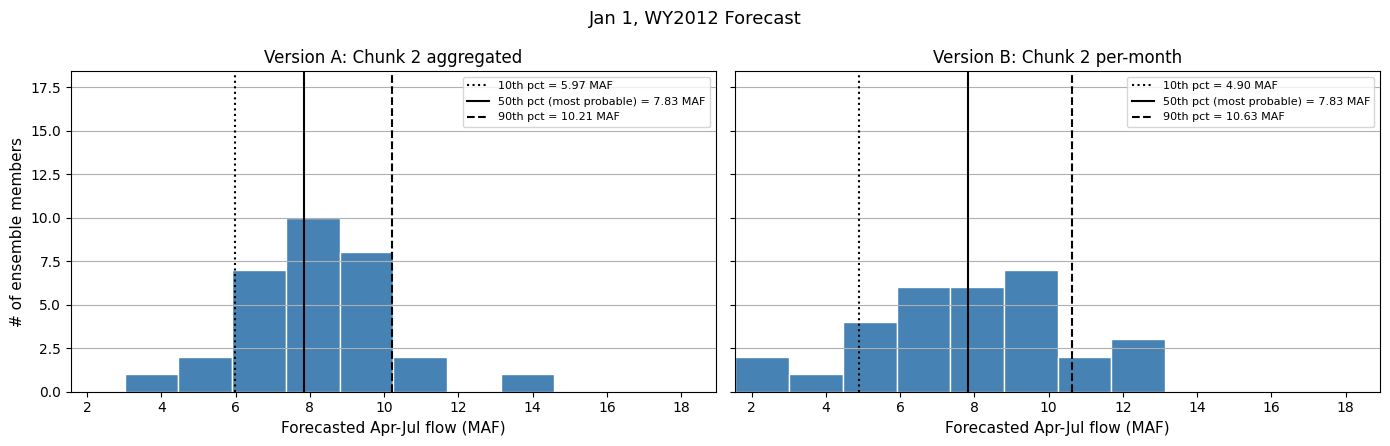

In [166]:
preds_jan_A, p10_jan_A, p50_jan_A, p90_jan_A = forecast_ensemble_v_agg(1, 1, FORECAST_WY)
preds_jan_B, p10_jan_B, p50_jan_B, p90_jan_B = forecast_ensemble_v_monthly(1, 1, FORECAST_WY)
plot_forecast_comparison(preds_jan_A, p10_jan_A, p50_jan_A, p90_jan_A,
                          preds_jan_B, p10_jan_B, p50_jan_B, p90_jan_B,
                          f"Jan 1, WY{FORECAST_WY} Forecast")

### FEB 1 FORECAST

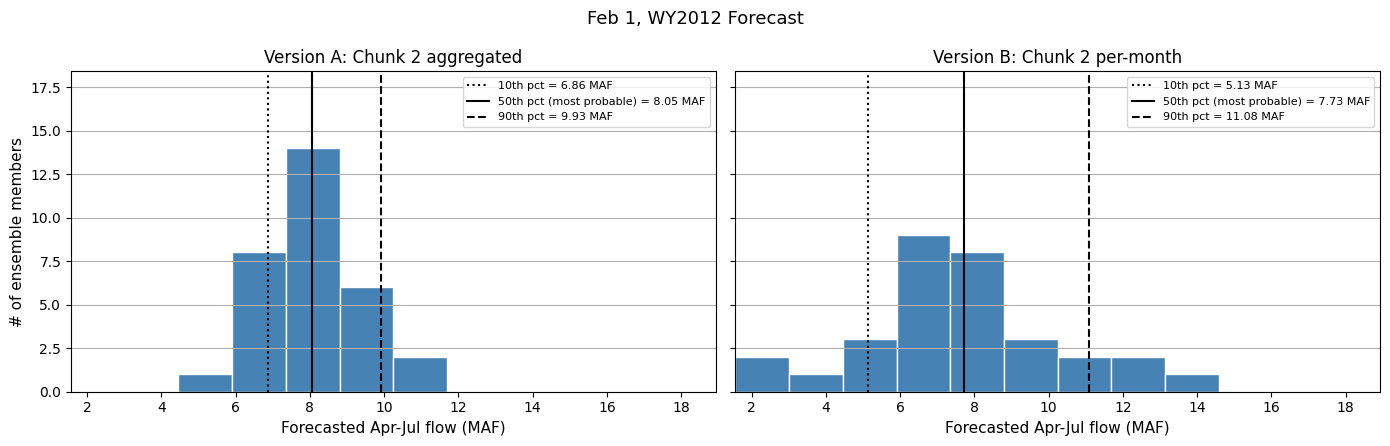

In [167]:
preds_feb_A, p10_feb_A, p50_feb_A, p90_feb_A = forecast_ensemble_v_agg(2, 1, FORECAST_WY)
preds_feb_B, p10_feb_B, p50_feb_B, p90_feb_B = forecast_ensemble_v_monthly(2, 1, FORECAST_WY)
plot_forecast_comparison(preds_feb_A, p10_feb_A, p50_feb_A, p90_feb_A,
                          preds_feb_B, p10_feb_B, p50_feb_B, p90_feb_B,
                          f"Feb 1, WY{FORECAST_WY} Forecast")

### MAR 1 FORECAST

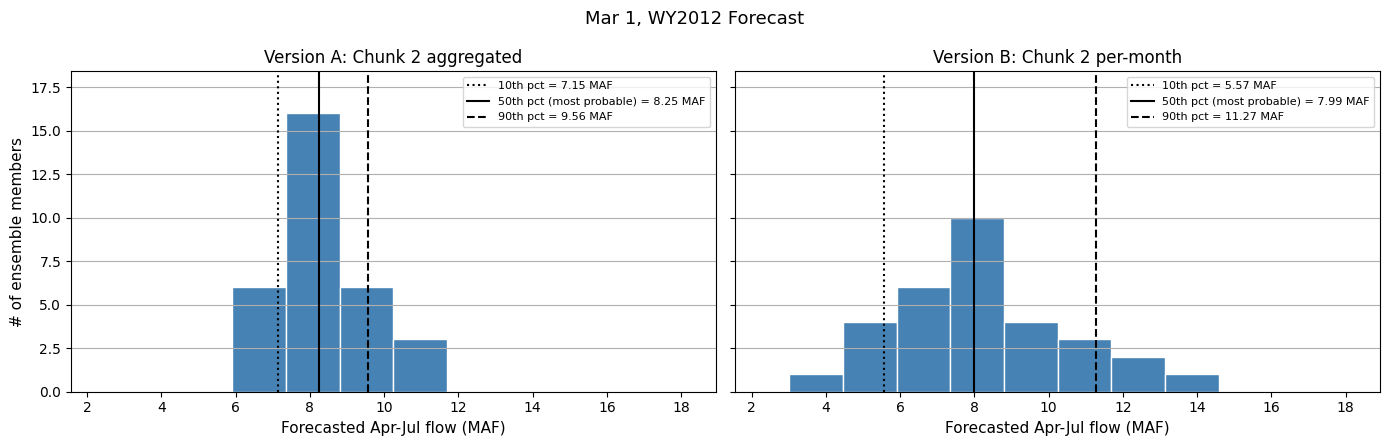

In [168]:
preds_mar_A, p10_mar_A, p50_mar_A, p90_mar_A = forecast_ensemble_v_agg(3, 1, FORECAST_WY)
preds_mar_B, p10_mar_B, p50_mar_B, p90_mar_B = forecast_ensemble_v_monthly(3, 1, FORECAST_WY)
plot_forecast_comparison(preds_mar_A, p10_mar_A, p50_mar_A, p90_mar_A,
                          preds_mar_B, p10_mar_B, p50_mar_B, p90_mar_B,
                          f"Mar 1, WY{FORECAST_WY} Forecast")

### **Discuss** and prepare to share your observations with the class:
#### - Did Version A and Version B ever disagree meaningfully -- either in the most-probable (50th pct) value or in how wide the spread was? At which issue date was the gap biggest?
#### - Did the forecast change between every issue date, or were some jumps bigger than others? Why might that be?
#### - Does the spread (10th-90th percentile) get narrower over time, stay the same, or something else? What does that tell you about how much uncertainty is really being resolved between Jan 1 and Mar 1 in this basin?

### THE REVEAL: how close were you?

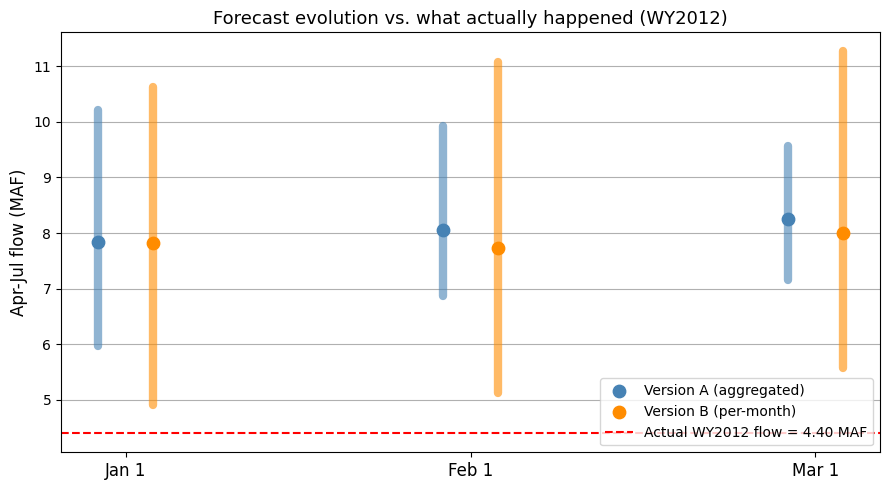

Actual WY2012 Apr-Jul flow: 4.40 MAF


In [169]:
actual = hindsight.loc[FORECAST_WY, "aprjul_flow"]

fig, ax = plt.subplots(figsize=(9, 5))
issue_dates = ["Jan 1", "Feb 1", "Mar 1"]
p10s_A = [p10_jan_A, p10_feb_A, p10_mar_A]
p50s_A = [p50_jan_A, p50_feb_A, p50_mar_A]
p90s_A = [p90_jan_A, p90_feb_A, p90_mar_A]
p10s_B = [p10_jan_B, p10_feb_B, p10_mar_B]
p50s_B = [p50_jan_B, p50_feb_B, p50_mar_B]
p90s_B = [p90_jan_B, p90_feb_B, p90_mar_B]

offset = 0.08
for i, (lo, mid, hi) in enumerate(zip(p10s_A, p50s_A, p90s_A)):
    x = i - offset
    ax.plot([x, x], [lo, hi], color="steelblue", linewidth=6, solid_capstyle="round", alpha=0.6)
    ax.scatter([x], [mid], color="steelblue", s=80, zorder=3, label="Version A (aggregated)" if i == 0 else None)

for i, (lo, mid, hi) in enumerate(zip(p10s_B, p50s_B, p90s_B)):
    x = i + offset
    ax.plot([x, x], [lo, hi], color="darkorange", linewidth=6, solid_capstyle="round", alpha=0.6)
    ax.scatter([x], [mid], color="darkorange", s=80, zorder=3, label="Version B (per-month)" if i == 0 else None)

ax.axhline(actual, color="red", linestyle="--", label=f"Actual WY{FORECAST_WY} flow = {actual:.2f} MAF")
ax.set_xticks(range(len(issue_dates)))
ax.set_xticklabels(issue_dates, fontsize=12)
ax.set_ylabel("Apr-Jul flow (MAF)", fontsize=12)
ax.set_title(f"Forecast evolution vs. what actually happened (WY{FORECAST_WY})", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y")
plt.tight_layout()
plt.show()

print(f"Actual WY{FORECAST_WY} Apr-Jul flow: {actual:.2f} MAF")

## A Real-World Consequence: Operating Tiers

Reclamation's Annual Operating Plan uses forecasts just like this one to help decide
how Lake Powell is operated for the year -- including whether **drought response**
planning gets triggered. The real logic depends on a lot more than one year's inflow
forecast (starting reservoir storage, releases, Lake Mead balancing, evaporation), so
what's below is a **simplified, invented threshold for illustration only** -- not
Reclamation's actual rule. But it's meant to give you a taste of how a forecast number
turns into a real operational decision.

In [170]:
# SIMPLIFIED, ILLUSTRATIVE THRESHOLD -- not Reclamation's real tier logic. Adjust this
# and re-run to see how the "decision" changes!
DROUGHT_CONCERN_THRESHOLD_MAF = 6.0

print("Version A (Chunk 2 aggregated):")
for d, mid in zip(issue_dates, p50s_A):
    status = "-> would raise drought concern" if mid < DROUGHT_CONCERN_THRESHOLD_MAF else "-> no concern flagged"
    print(f"  {d} most-probable forecast: {mid:.2f} MAF {status}")

print("\nVersion B (Chunk 2 per-month):")
for d, mid in zip(issue_dates, p50s_B):
    status = "-> would raise drought concern" if mid < DROUGHT_CONCERN_THRESHOLD_MAF else "-> no concern flagged"
    print(f"  {d} most-probable forecast: {mid:.2f} MAF {status}")

Version A (Chunk 2 aggregated):
  Jan 1 most-probable forecast: 7.83 MAF -> no concern flagged
  Feb 1 most-probable forecast: 8.05 MAF -> no concern flagged
  Mar 1 most-probable forecast: 8.25 MAF -> no concern flagged

Version B (Chunk 2 per-month):
  Jan 1 most-probable forecast: 7.83 MAF -> no concern flagged
  Feb 1 most-probable forecast: 7.73 MAF -> no concern flagged
  Mar 1 most-probable forecast: 7.99 MAF -> no concern flagged


### **Discuss** and prepare to share your observations with the class:
#### - Did the "drought concern" call change at any point between Jan 1 and Mar 1? Would a water manager have had time to act if it did?
#### - If you were designing a real early-warning system, would you rather have an early forecast with a wide range, or a late forecast with a narrow one? What's the tradeoff?
#### - What's one thing you'd add to this model if you had more variables to work with?